# SIH 26143 -- SAR oil-spill detection -> drift backtracking -> AIS vessel attribution

One pipeline, one switch (`MODE`):

| | `MODE = "DEMO"` (default) | `MODE = "REAL"` |
|---|---|---|
| SAR | hard-coded georeferenced synthetic scenes (4 Port Said cases) | your georeferenced Sentinel-1 GeoTIFFs (own CRS + own timestamp, never invented) |
| Wind / current | hard-coded constants with explicit conventions | your GRIB / CSV / NetCDF (coverage-checked, never extrapolated) |
| AIS | synthetic traffic + injected test vessels (self-check) | your real AIS CSV |
| Detector | Otsu vs trained DeepLabV3+ **benchmarked**, best auto-selected | same, benchmarked on your labelled set if provided |

**Read this first -- what a DEMO result does and does not prove.** It proves the plumbing, conventions and ranking logic work end-to-end. It does *not* prove real-world accuracy: the synthetic ground truth is generated with the same forcing model that ranks it. Every output carries its provenance and warnings.

Stages: `detection -> forcing -> backward reconstruction (NumPy, +PyGNOME cross-check) -> AIS anomaly + time-synchronous attribution -> digital twin (NumPy or OpenOil) -> fusion -> report`.

In [1]:
# ---- 0. environment ----
import importlib, subprocess, sys
need = {"xarray": "xarray", "netCDF4": "netCDF4", "rasterio": "rasterio", "affine": "affine", "pyproj": "pyproj",
        "skimage": "scikit-image", "sklearn": "scikit-learn", "cv2": "opencv-python-headless", "scipy": "scipy"}
optional = {"cfgrib": "cfgrib", "opendrift": "opendrift"}           # GRIB wind files / OpenOil engine
for mod, pipname in {**need, **optional}.items():
    try: importlib.import_module(mod)
    except ImportError:
        print("installing", pipname); subprocess.run([sys.executable, "-m", "pip", "install", "-q", pipname], check=False)
print("environment ready")

environment ready


In [2]:
# ---- 1. locate the repository ----
from pathlib import Path
import os
import sys
import logging
import warnings

warnings.filterwarnings("ignore")

# Find the repository root by looking for oilspill_pipeline/
PROJECT_DIR = Path.cwd()

while PROJECT_DIR != PROJECT_DIR.parent:
    if (PROJECT_DIR / "oilspill_pipeline").is_dir():
        break
    PROJECT_DIR = PROJECT_DIR.parent

if not (PROJECT_DIR / "oilspill_pipeline").is_dir():
    raise FileNotFoundError(
        "Could not locate the project root containing "
        "'oilspill_pipeline/'. "
        "Run this notebook from inside the repository."
    )

sys.path.insert(0, str(PROJECT_DIR))

# Repository-relative directories
INPUT_DIR = PROJECT_DIR / "input"
OUTPUT_DIR = PROJECT_DIR / "sample_outputs"

# Make sure the input folder exists
INPUT_DIR.mkdir(exist_ok=True)

from oilspill_pipeline.config import Config, demo_fast_config
from oilspill_pipeline.pipeline import Pipeline
from oilspill_pipeline import setup_env

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s %(message)s"
)

print("Project:", PROJECT_DIR)
print("Input:", INPUT_DIR)
print("Output:", OUTPUT_DIR)

Project: c:\Users\fkrii\OneDrive\Desktop\SIH26143_merged_pipeline\proj
Input: c:\Users\fkrii\OneDrive\Desktop\SIH26143_merged_pipeline\proj\input
Output: c:\Users\fkrii\OneDrive\Desktop\SIH26143_merged_pipeline\proj\sample_outputs


In [3]:
# ================================================================
# REAL-DATA TIME COVERAGE HELPERS
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np


def _time_range_from_series(times):
    """Return (min_time, max_time) from a timestamp-like iterable."""
    
    t = pd.to_datetime(times, errors="coerce", utc=True)
    t = t.dropna()

    if len(t) == 0:
        return None

    return (
        t.min().tz_localize(None),
        t.max().tz_localize(None),
    )


def _time_values_from_csv(path):
    """
    Extract timestamps from an AIS/CSV file.

    Handles common AIS timestamp names such as:
    BaseDateTime, timestamp, Timestamp, time, datetime, DateTime.
    """

    df = pd.read_csv(path)

    candidates = [
        "BaseDateTime",
        "timestamp",
        "Timestamp",
        "time",
        "Time",
        "datetime",
        "DateTime",
        "# Timestamp",
    ]

    for col in candidates:
        if col in df.columns:
            return pd.to_datetime(
                df[col],
                errors="coerce",
                utc=True
            )

    # Fallback: inspect columns whose names look temporal.
    for col in df.columns:
        name = str(col).lower()

        if any(
            key in name
            for key in ["time", "date", "timestamp"]
        ):
            values = pd.to_datetime(
                df[col],
                errors="coerce",
                utc=True
            )

            if values.notna().any():
                return values

    raise ValueError(
        f"Could not identify a timestamp column in {path.name}"
    )


def _time_values_from_netcdf(path):
    """
    Extract time values from a NetCDF/HYCOM file.
    """

    import xarray as xr

    ds = xr.open_dataset(path)

    candidates = [
        "time",
        "valid_time",
        "datetime",
        "date",
    ]

    for name in candidates:
        if name in ds.coords:
            values = ds[name].values
            ds.close()
            return pd.to_datetime(
                values,
                errors="coerce",
                utc=True
            )

        if name in ds.variables:
            values = ds[name].values
            ds.close()
            return pd.to_datetime(
                values,
                errors="coerce",
                utc=True
            )

    ds.close()

    raise ValueError(
        f"Could not identify a time coordinate in {path.name}"
    )


def _time_values_from_grib(path):
    """
    Extract time values from a GRIB file.

    Uses cfgrib when available.
    """

    import xarray as xr

    ds = xr.open_dataset(
        path,
        engine="cfgrib"
    )

    candidates = [
        "time",
        "valid_time",
    ]

    for name in candidates:
        if name in ds.coords:
            values = ds[name].values
            ds.close()
            return pd.to_datetime(
                values,
                errors="coerce",
                utc=True
            )

        if name in ds.variables:
            values = ds[name].values
            ds.close()
            return pd.to_datetime(
                values,
                errors="coerce",
                utc=True
            )

    ds.close()

    raise ValueError(
        f"Could not identify a time coordinate in {path.name}"
    )


def discover_time_datasets(input_dir):
    """
    Search input/ recursively for time-dependent datasets.

    Returns:
        {
            "AIS": [...],
            "WIND": [...],
            "CURRENT": [...]
        }
    """

    input_dir = Path(input_dir)

    datasets = {
        "AIS": [],
        "WIND": [],
        "CURRENT": [],
    }

    # ------------------------------------------------------------
    # CSV files
    # ------------------------------------------------------------

    for path in input_dir.rglob("*.csv"):

        name = path.name.lower()

        try:
            times = _time_values_from_csv(path)

            if "ais" in name:
                datasets["AIS"].append(
                    (path, times)
                )

        except Exception as e:
            print(
                f"Skipping CSV {path.name}: {e}"
            )


    # ------------------------------------------------------------
    # NetCDF / HYCOM current files
    # ------------------------------------------------------------

    for pattern in ["*.nc", "*.nc4", "*.netcdf"]:

        for path in input_dir.rglob(pattern):

            try:
                times = _time_values_from_netcdf(path)

                name = path.name.lower()

                if (
                    "hycom" in name
                    or "current" in name
                    or "curr" in name
                    or "water_u" in name
                    or "water_v" in name
                ):
                    datasets["CURRENT"].append(
                        (path, times)
                    )

            except Exception as e:
                print(
                    f"Skipping NetCDF {path.name}: {e}"
                )


    # ------------------------------------------------------------
    # GRIB wind files
    # ------------------------------------------------------------

    for pattern in ["*.grib", "*.grib2", "*.grb", "*.grb2"]:

        for path in input_dir.rglob(pattern):

            try:
                times = _time_values_from_grib(path)

                name = path.name.lower()

                if (
                    "wind" in name
                    or "era5" in name
                    or "u10" in name
                    or "v10" in name
                ):
                    datasets["WIND"].append(
                        (path, times)
                    )

            except Exception as e:
                print(
                    f"Skipping GRIB {path.name}: {e}"
                )

    return datasets


def summarize_time_coverage(datasets):
    """
    Calculate min/max coverage for every discovered dataset.
    """

    coverage = {}

    for category, files in datasets.items():

        ranges = []

        for path, times in files:

            t = pd.to_datetime(
                times,
                errors="coerce",
                utc=True
            ).dropna()

            if len(t) == 0:
                continue

            t = t.tz_convert(None)

            ranges.append(
                (
                    t.min(),
                    t.max(),
                    path
                )
            )

        if ranges:

            coverage[category] = {
                "min": min(r[0] for r in ranges),
                "max": max(r[1] for r in ranges),
                "files": ranges,
            }

    return coverage


def find_common_time_range(coverage):
    """
    Find the intersection of the available time ranges.

    The common interval is:

        max(all minimum times)
        ...
        min(all maximum times)
    """

    if not coverage:
        return None

    common_start = max(
        info["min"]
        for info in coverage.values()
    )

    common_end = min(
        info["max"]
        for info in coverage.values()
    )

    if common_start > common_end:
        return None

    return common_start, common_end


def nearest_available_time(requested_time, times):
    """
    Return the timestamp in `times` closest to requested_time.
    """

    requested_time = pd.Timestamp(requested_time)

    times = pd.to_datetime(
        times,
        errors="coerce"
    )

    times = times.dropna()

    if len(times) == 0:
        return None

    # Remove timezone if present.
    if getattr(times, "tz", None) is not None:
        times = times.tz_convert(None)

    differences = np.abs(
        times - requested_time
    )

    idx = differences.argmin()

    return pd.Timestamp(times.iloc[idx])


def resolve_nearest_times(requested_time, datasets):
    """
    Find the nearest available timestamp for every dataset category.
    """

    resolved = {}

    for category, files in datasets.items():

        category_matches = []

        for path, times in files:

            nearest = nearest_available_time(
                requested_time,
                times
            )

            if nearest is not None:

                difference = abs(
                    nearest - requested_time
                )

                category_matches.append(
                    {
                        "file": path,
                        "timestamp": nearest,
                        "difference": difference,
                    }
                )

        if category_matches:

            # Use the closest observation across all files.
            best = min(
                category_matches,
                key=lambda x: x["difference"]
            )

            resolved[category] = best

    return resolved

In [50]:
# ---- 2. THE SWITCH + CONFIGURATION ----

# DEFAULT MODE SET TO REAL
# To switch simply change the below variable MODE to MODE="DEMO"
MODE = "REAL"                 # "DEMO" = built-in demonstration | "REAL" = user-provided data
FAST = True                   # True = small/fast configuration | False = full-quality configuration
OUTPUT_DIR = str(PROJECT_DIR / "outputs")

# This flag records whether REAL mode had to fall back to
# synthetic AIS/environmental forcing because the uploaded
# time-dependent datasets did not overlap.
REAL_DATA_FALLBACK = False


# ================================================================
# BASE CONFIGURATION
# ================================================================

if MODE == "DEMO" and FAST:
    cfg = demo_fast_config(OUTPUT_DIR)
else:
    cfg = Config(output_dir=OUTPUT_DIR)

cfg.mode = MODE


# ================================================================
# CLASSIFIER BUNDLE
# ================================================================
#
# model_weights.pt contains the weights of the winning model from
# the training comparison:
#
#     DeepLabV3+
#          vs
#     Hybrid CNN + Transformer
#          ↓
#       evaluation
#          ↓
#       winner
#          ↓
#     model_weights.pt
#
# deployment_config.json tells the runtime loader which architecture
# those weights belong to.
#
# IMPORTANT:
# The existing backend may use legacy names such as "DeepLabDetector".
# Do not interpret that name as meaning that the saved weights must
# be DeepLabV3+ weights.
# ================================================================

cfg.detection.bundle_dir = str(PROJECT_DIR / "bundle")

# Keep the existing runtime detector selection behavior for now.
cfg.detection.mode = "auto"


# ================================================================
# DEMO MODE
# ================================================================

if MODE == "DEMO":

    # Built-in synthetic forcing.
    #
    # Wind direction = direction wind blows FROM.
    # Current direction = direction water flows TOWARD.

    cfg.forcing.hardcoded_wind_speed_ms = 5.0
    cfg.forcing.hardcoded_wind_dir_from_deg = 315.0

    cfg.forcing.hardcoded_current_speed_ms = 0.15
    cfg.forcing.hardcoded_current_dir_to_deg = 70.0

    cfg.forcing.windage_frac = 0.03

    print("MODE = DEMO")
    print("Using built-in synthetic scenario and forcing.")


# ================================================================
# REAL MODE
# ================================================================

elif MODE == "REAL":

    # ============================================================
    # 1. DISCOVER AVAILABLE TIME-DEPENDENT DATA
    # ============================================================

    datasets = discover_time_datasets(INPUT_DIR)

    coverage = summarize_time_coverage(datasets)

    print("\n" + "=" * 70)
    print("AVAILABLE DATA COVERAGE")
    print("=" * 70)

    for category, info in coverage.items():

        print(
            f"{category:10s}: "
            f"{info['min']}  →  {info['max']}"
        )

        for start, end, path in info["files"]:
            print(
                f"             {path.name}: "
                f"{start} → {end}"
            )


    # ============================================================
    # 2. FIND COMMON TIME RANGE
    # ============================================================

    common_range = find_common_time_range(coverage)


    # ============================================================
    # 3A. NO COMMON RANGE → SYNTHETIC FALLBACK
    # ============================================================

    if common_range is None:

        REAL_DATA_FALLBACK = True

        print("\n" + "!" * 70)
        print("WARNING: NO COMMON REAL-DATA TIME RANGE")
        print("!" * 70)

        print(
            "\nAIS, wind and/or current datasets do not have "
            "a common overlapping time range."
        )

        print(
            "\nThe pipeline will NOT stop."
        )

        print(
            "The following fallback will be used:"
        )

        print(
            "  • REAL SAR imagery"
        )
        print(
            "  • SYNTHETIC / HARDCODED wind"
        )
        print(
            "  • SYNTHETIC / HARDCODED current"
        )
        print(
            "  • SYNTHETIC AIS"
        )

        print(
            "\nNo SAR timestamp will be requested because "
            "there is no valid real-data time range."
        )

        print(
            "\nThis fallback exists so the complete pipeline, "
            "website and agent can be developed and tested "
            "without waiting for the final datasets."
        )

        print(
            "\nIMPORTANT:"
        )

        print(
            "This run is NOT valid for real-world vessel attribution."
        )

        print(
            "Its outputs are for pipeline / UI / agent / "
            "algorithm testing only."
        )

        print("!" * 70)


        # ========================================================
        # USE SYNTHETIC ENVIRONMENTAL FORCING
        # ========================================================

        cfg.forcing.source = "hardcoded"

        cfg.forcing.hardcoded_wind_speed_ms = 5.0
        cfg.forcing.hardcoded_wind_dir_from_deg = 315.0

        cfg.forcing.hardcoded_current_speed_ms = 0.15
        cfg.forcing.hardcoded_current_dir_to_deg = 70.0

        cfg.forcing.windage_frac = 0.03


        # ========================================================
        # USE SYNTHETIC AIS
        # ========================================================

        cfg.ais.source = "synthetic"


        # ========================================================
        # SELECT SAR FILE
        # ========================================================

        sar_files = sorted(
            list(INPUT_DIR.glob("*.tif")) +
            list(INPUT_DIR.glob("*.tiff"))
        )

        if not sar_files:
            raise FileNotFoundError(
                f"No .tif/.tiff SAR files found in {INPUT_DIR}"
            )

        # If only one SAR file is available, automatically use it.
        if len(sar_files) == 1:

            sar_path = sar_files[0]

            print("\nOnly one SAR file found.")
            print("Automatically selected:", sar_path.name)

        else:

            print("\nAvailable SAR files:")

            for i, path in enumerate(sar_files, start=1):
                print(f"  [{i}] {path.name}")

            selection = input(
                "\nEnter the number of the SAR file to process(indexing starts from 1): "
            ).strip()

            try:
                selection = int(selection)

            except ValueError:
                raise ValueError(
                    "Please enter the number shown next to "
                    "the desired SAR file."
                )

            if not 1 <= selection <= len(sar_files):
                raise ValueError(
                    f"Invalid selection. Enter a number from "
                    f"1 to {len(sar_files)}."
                )

            sar_path = sar_files[selection - 1]


        # ========================================================
        # SAR TIMESTAMP
        # ========================================================
        #
        # NO USER INPUT HERE.
        #
        # If the SAR filename contains a date, use that date.
        # Otherwise use a fixed synthetic reference timestamp.
        #
        # This timestamp is ONLY an internal reference for the
        # synthetic fallback and must not be interpreted as the
        # actual SAR acquisition time.
        # ========================================================

        acquisition_time = None

        # --------------------------------------------------------
        # First try to extract timestamp from raster metadata
        # --------------------------------------------------------

        try:

            import rasterio

            with rasterio.open(sar_path) as src:

                tags = src.tags()

                timestamp_keys = [
                    "ACQUISITION_TIME",
                    "acquisition_time",
                    "DATETIME",
                    "datetime",
                    "TIMESTAMP",
                    "timestamp",
                ]

                for key in timestamp_keys:

                    if key in tags:

                        try:
                            acquisition_time = pd.Timestamp(
                                tags[key]
                            )
                            break

                        except Exception:
                            pass

        except Exception:
            pass


        # --------------------------------------------------------
        # If metadata did not contain a timestamp, try filename
        # --------------------------------------------------------

        if acquisition_time is None:

            import re

            filename = sar_path.stem

            # YYYY-MM-DD
            match = re.search(
                r"(20\d{2})[-_](\d{2})[-_](\d{2})",
                filename
            )

            if match:

                acquisition_time = pd.Timestamp(
                    f"{match.group(1)}-"
                    f"{match.group(2)}-"
                    f"{match.group(3)}"
                )


        # --------------------------------------------------------
        # Final fallback: synthetic reference time
        # --------------------------------------------------------

        if acquisition_time is None:

            acquisition_time = pd.Timestamp(
                "2000-01-01 00:00:00"
            )

            timestamp_source = "SYNTHETIC_REFERENCE"

        else:

            timestamp_source = "SAR_METADATA_OR_FILENAME"


        # ========================================================
        # BUILD REAL SAR CASE
        # ========================================================

        cfg.real_cases = [
            dict(
                case_id=sar_path.stem,
                label=sar_path.stem,
                sar_path=str(sar_path),

                acquisition_time=acquisition_time,

                polarisation_band=1,
                units="db",

                # None causes the backend to generate/use
                # synthetic AIS in this fallback configuration.
                ais_csv=None,
            ),
        ]


        print("\n" + "=" * 70)
        print("REAL SAR + SYNTHETIC ENVIRONMENT FALLBACK")
        print("=" * 70)

        print(
            "Selected SAR:",
            sar_path.name
        )

        print(
            "Internal reference time:",
            acquisition_time
        )

        print(
            "Timestamp source:",
            timestamp_source
        )

        print(
            "Wind: SYNTHETIC / HARDCODED"
        )

        print(
            "Current: SYNTHETIC / HARDCODED"
        )

        print(
            "AIS: SYNTHETIC"
        )

        print(
            "Purpose: PIPELINE / UI / AGENT TESTING ONLY"
        )

        print(
            "Real attribution validity: NOT ESTABLISHED"
        )

        print("=" * 70)

    # ============================================================
    # 3B. COMMON RANGE EXISTS → NORMAL REAL-DATA PATH
    # ============================================================

    else:

        common_start, common_end = common_range

        print("\n" + "=" * 70)
        print("VALID COMMON TIME RANGE")
        print("=" * 70)

        print(
            f"{common_start}  →  {common_end}"
        )

        print(
            "\nThe SAR acquisition timestamp must fall "
            "within this common range."
        )


        # --------------------------------------------------------
        # Configure REAL environmental forcing
        # --------------------------------------------------------

        cfg.forcing.source = "files"

        # These will be populated once the actual datasets
        # are available in input/.
        #
        # The current discovery functions identify the datasets,
        # but the actual forcing backend still needs their paths.
        #
        # These can be connected to the discovered files later.
        #
        # cfg.forcing.wind_path = ...
        # cfg.forcing.current_path = ...
        # cfg.forcing.current_verified_surface = True


        # --------------------------------------------------------
        # Configure REAL AIS
        # --------------------------------------------------------

        cfg.ais.source = "csv"

        # The actual AIS CSV path will be connected here once
        # the final AIS dataset is placed in input/.
        #
        # cfg.ais.csv_path = ...
        # cfg.ais.column_map = {}


        # ========================================================
        # 4. SELECT SAR FILE
        # ========================================================

        sar_files = sorted(
            list(INPUT_DIR.glob("*.tif")) +
            list(INPUT_DIR.glob("*.tiff"))
        )

        if not sar_files:

            raise FileNotFoundError(
                f"No .tif/.tiff SAR files found in {INPUT_DIR}"
            )


        print("\nAvailable SAR files:")

        for i, path in enumerate(sar_files, start=1):

            print(
                f"  [{i}] {path.name}"
            )


        selection = input(
            "\nEnter the number of the SAR file to process: "
        ).strip()


        try:

            selection = int(selection)

        except ValueError:

            raise ValueError(
                "Please enter the number shown next to "
                "the desired SAR file."
            )


        if not 1 <= selection <= len(sar_files):

            raise ValueError(
                f"Invalid selection. Enter a number from "
                f"1 to {len(sar_files)}."
            )


        sar_path = sar_files[selection - 1]


        # ========================================================
        # 5. USER ENTERS ASSUMED SAR TIMESTAMP
        # ========================================================

        print(
            "\nSelected SAR:",
            sar_path.name
        )

        print(
            "\nEnter an assumed SAR acquisition timestamp."
        )

        print(
            f"Valid range: "
            f"{common_start}  →  {common_end}"
        )


        acquisition_time = input(
            "\nTimestamp (YYYY-MM-DD HH:MM:SS): "
        ).strip()


        try:

            acquisition_time = pd.Timestamp(
                acquisition_time
            )

        except Exception as e:

            raise ValueError(
                "Invalid timestamp. Use "
                "'YYYY-MM-DD HH:MM:SS'."
            ) from e


        # --------------------------------------------------------
        # Check common range
        # --------------------------------------------------------

        if not (
            common_start
            <= acquisition_time
            <= common_end
        ):

            raise ValueError(

                "\nTimestamp is outside the common "
                "coverage of the available datasets.\n"

                f"Valid range: "
                f"{common_start} → {common_end}\n"

                f"Entered:      "
                f"{acquisition_time}"
            )


        # ========================================================
        # 6. RESOLVE NEAREST AVAILABLE OBSERVATIONS
        # ========================================================

        resolved_times = resolve_nearest_times(
            acquisition_time,
            datasets
        )


        print("\n" + "=" * 70)
        print("TIME RESOLUTION")
        print("=" * 70)

        print(
            "Requested SAR time:",
            acquisition_time
        )


        for category, result in resolved_times.items():

            delta = result["difference"]

            print(
                f"{category:10s}: "
                f"{result['timestamp']} "
                f"(Δ {delta})"
            )


        print(
            "\nThe SAR timestamp remains the user-provided time; "
            "nearest available observations are used for "
            "discrete AIS/environmental datasets."
        )


        # ========================================================
        # 7. BUILD REAL CASE
        # ========================================================

        cfg.real_cases = [

            dict(

                case_id=sar_path.stem,

                label=sar_path.stem,

                sar_path=str(sar_path),

                acquisition_time=acquisition_time,

                polarisation_band=1,

                units="db",

                ais_csv=None,
            ),
        ]


        print("\n" + "=" * 70)
        print("REAL DATA MODE")
        print("=" * 70)

        print(
            "Selected SAR:",
            sar_path.name
        )

        print(
            "Acquisition time:",
            acquisition_time
        )

        print(
            "Wind: REAL DATA CONFIGURATION"
        )

        print(
            "Current: REAL DATA CONFIGURATION"
        )

        print(
            "AIS: REAL DATA CONFIGURATION"
        )

        print(
            "Timestamp source: "
            "USER-PROVIDED / PROOF-OF-CONCEPT"
        )

        print("=" * 70)


# ================================================================
# UNKNOWN MODE
# ================================================================

else:

    raise ValueError(
        f"Unknown MODE={MODE!r}. "
        "Use 'DEMO' or 'REAL'."
    )


# ================================================================
# PHYSICS ENGINES
# ================================================================

cfg.physics.backtrack_engine = "numpy"

cfg.physics.forward_engine = "numpy"

cfg.physics.run_oil_age_screening = False


# ================================================================
# FINAL CONFIGURATION SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("FINAL PIPELINE CONFIGURATION")
print("=" * 70)

print(
    f"MODE:             {cfg.mode}"
)

print(
    f"REAL DATA FALLBACK: {REAL_DATA_FALLBACK}"
)

print(
    f"FORCING:           {cfg.forcing.source}"
)

print(
    f"AIS:               {cfg.ais.source}"
)

print(
    f"BACKTRACK ENGINE:  {cfg.physics.backtrack_engine}"
)

print(
    f"FORWARD ENGINE:    {cfg.physics.forward_engine}"
)

print(
    f"AGE SCREENING:     {cfg.physics.run_oil_age_screening}"
)

print(
    f"MODEL BUNDLE:      {cfg.detection.bundle_dir}"
)

print("=" * 70)


# ================================================================
# FINAL SAFETY MESSAGE FOR FALLBACK RUNS
# ================================================================

if MODE == "REAL" and REAL_DATA_FALLBACK:

    print("\n" + "!" * 70)
    print("SYNTHETIC FALLBACK ACTIVE")
    print("!" * 70)

    print(
        "REAL SAR is being processed, but AIS and environmental "
        "forcing are synthetic."
    )

    print(
        "Use this run to test the complete detection → "
        "backtracking → AIS → digital twin → fusion → "
        "website/agent pipeline."
    )

    print(
        "DO NOT interpret vessel attribution as real-world evidence."
    )

    print("!" * 70)


AVAILABLE DATA COVERAGE

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

AIS, wind and/or current datasets do not have a common overlapping time range.

The pipeline will NOT stop.
The following fallback will be used:
  • REAL SAR imagery
  • SYNTHETIC / HARDCODED wind
  • SYNTHETIC / HARDCODED current
  • SYNTHETIC AIS

No SAR timestamp will be requested because there is no valid real-data time range.

This fallback exists so the complete pipeline, website and agent can be developed and tested without waiting for the final datasets.

IMPORTANT:
This run is NOT valid for real-world vessel attribution.
Its outputs are for pipeline / UI / agent / algorithm testing only.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Available SAR files:
  [1] sample1_oil.tif
  [2] sample2_oil.tif
  [3] sample3_oil.tif
  [4] sample4_oil.tif
  [5] sample5_oil.tif


WARNING CPLE_AppDefined in sample1_oil.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.



REAL SAR + SYNTHETIC ENVIRONMENT FALLBACK
Selected SAR: sample1_oil.tif
Internal reference time: 2000-01-01 00:00:00
Timestamp source: SYNTHETIC_REFERENCE
Wind: SYNTHETIC / HARDCODED
Current: SYNTHETIC / HARDCODED
AIS: SYNTHETIC
Purpose: PIPELINE / UI / AGENT TESTING ONLY
Real attribution validity: NOT ESTABLISHED

FINAL PIPELINE CONFIGURATION
MODE:             REAL
REAL DATA FALLBACK: True
FORCING:           hardcoded
AIS:               synthetic
BACKTRACK ENGINE:  numpy
FORWARD ENGINE:    numpy
AGE SCREENING:     False
MODEL BUNDLE:      c:\Users\fkrii\OneDrive\Desktop\SIH26143_merged_pipeline\proj\bundle

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
SYNTHETIC FALLBACK ACTIVE
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
REAL SAR is being processed, but AIS and environmental forcing are synthetic.
Use this run to test the complete detection → backtracking → AIS → digital twin → fusion → website/agent pipeline.
DO NOT interpret vesse

In [51]:
# ---- 3. optional heavy setup (all OFF by default) ----
TRAIN_CLASSIFIER_IF_MISSING = False        # True -> executes oil_spill_pipeline_hardened.ipynb (hours on GPU) if no .pt bundle exists
TRAINING_NOTEBOOK = "oil_spill_pipeline_hardened.ipynb"
BUILD_PYGNOME_ENV = False                  # True -> micromamba env with PyGNOME (needed for backtrack_engine "pygnome"/"both")

if TRAIN_CLASSIFIER_IF_MISSING:
    setup_env.train_if_missing(cfg.detection.bundle_dir, TRAINING_NOTEBOOK)
if BUILD_PYGNOME_ENV:
    cfg.physics.pygnome_python = setup_env.ensure_pygnome_env()
print("classifier bundle present:", setup_env.bundle_ready(cfg.detection.bundle_dir))

classifier bundle present: True


In [52]:
# ---- 4. RUN ----
pipe = Pipeline(cfg)
results = pipe.run()
print("\nDetector chosen:", pipe.selected_detector, "--", pipe.detector_choice_reason)

INFO Detector selected: deeplab -- No labelled benchmark data -> trusting the trained model (its own test metrics are in the bundle config)  [benchmark data: none available]
INFO === sample1_oil ===
WARNING CPLE_AppDefined in sample1_oil.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
WARNING CPLE_AppDefined in TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


***OIL DETECTED***


INFO [Stage 1] OOF mean residual (m): {'CV': 160.54, 'MLP': 164.36, 'RNN': 161.72, 'MLP+RNN': 160.13} -> selected MLP+RNN



Detector chosen: deeplab -- No labelled benchmark data -> trusting the trained model (its own test metrics are in the bundle config)  [benchmark data: none available]


In [53]:
#to view a tiff image run this cell and the next one
%matplotlib inline

Found 4 TIFF file(s):

[1] sample1_oil.tif
[2] sample2_oil.tif
[3] sample3_oil.tif
[4] sample4_oil.tif


WARNING CPLE_AppDefined in sample1_oil.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
WARNING CPLE_AppDefined in TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.



Loading: sample1_oil.tif
Raster shape: (2, 2048, 2048)
Dtype: float32
CRS: EPSG:4326
Bounds: BoundingBox(left=3.9656639450910203, bottom=55.14999011252874, right=4.1496389152786985, top=55.33396508271642)


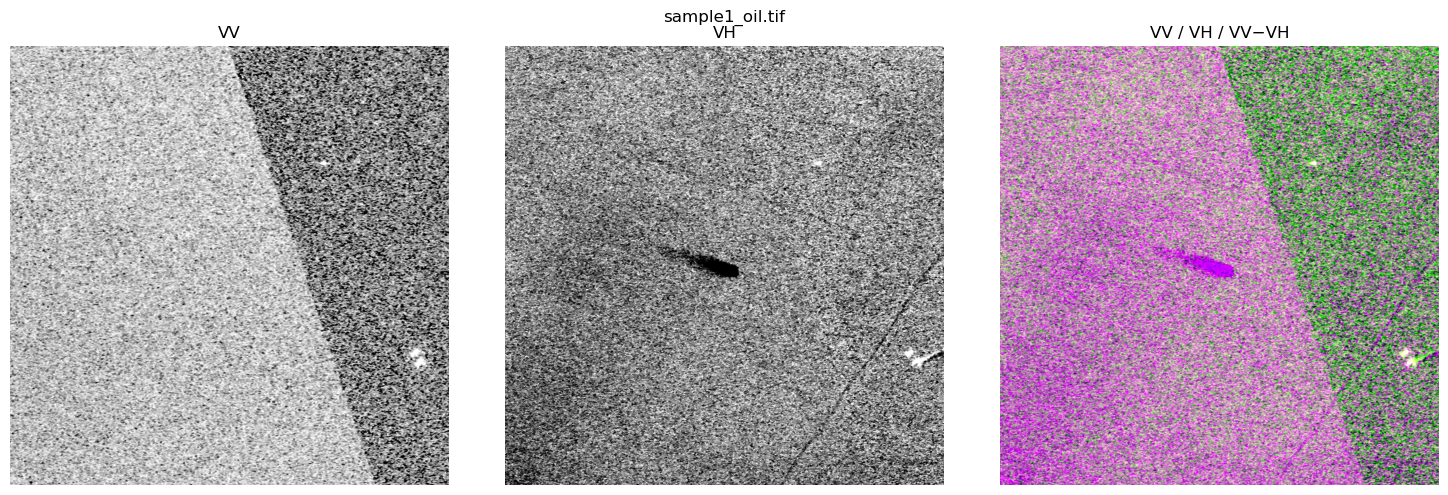


Statistics
--------------------------------------------------
VV     : mean=-34.271, min=-54.121, max=-1.993
VH     : mean=-20.784, min=-38.246, max=5.546
VV-VH  : mean=-13.486, min=-33.451, max=11.361


In [61]:
# ---- SAR TIFF VIEWER ----
%matplotlib inline

import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Find TIFF files
tiff_files = sorted(
    list(INPUT_DIR.glob("*.tif")) +
    list(INPUT_DIR.glob("*.tiff"))
)

if not tiff_files:
    raise FileNotFoundError(f"No TIFF files found in {INPUT_DIR}")

print(f"Found {len(tiff_files)} TIFF file(s):\n")

for i, path in enumerate(tiff_files, start=1):
    print(f"[{i}] {path.name}")

idx = int(input("\nEnter TIFF number to view(indexing starts from 1): "))

if idx < 1 or idx > len(tiff_files):
    raise ValueError(
        f"Please enter a number between 1 and {len(tiff_files)}."
    )

tiff_path = tiff_files[idx - 1]

print(f"\nLoading: {tiff_path.name}")

# Read GeoTIFF with rasterio
with rasterio.open(tiff_path) as src:
    img = src.read()
    crs = src.crs
    bounds = src.bounds

print("Raster shape:", img.shape)
print("Dtype:", img.dtype)
print("CRS:", crs)
print("Bounds:", bounds)

# We expect:
# (2, height, width)
if img.ndim != 3 or img.shape[0] != 2:
    raise ValueError(
        f"Expected a 2-channel SAR TIFF with shape "
        f"(2, H, W), but got {img.shape}"
    )

# Band 1 = VV
# Band 2 = VH
vv = img[0].astype(np.float32)
vh = img[1].astype(np.float32)

# VV - VH
vv_vh = vv - vh


def robust_normalize(x, low=2, high=98):
    lo, hi = np.percentile(x, [low, high])
    return np.clip(
        (x - lo) / (hi - lo + 1e-8),
        0,
        1
    )


# Normalize only for visualization
vv_display = robust_normalize(vv)
vh_display = robust_normalize(vh)
vv_vh_display = robust_normalize(vv_vh)

# False-color composite
# R = VV
# G = VH
# B = VV - VH
rgb = np.stack(
    [
        vv_display,
        vh_display,
        vv_vh_display
    ],
    axis=-1
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    vv_display,
    cmap="gray"
)
axes[0].set_title("VV")
axes[0].axis("off")

axes[1].imshow(
    vh_display,
    cmap="gray"
)
axes[1].set_title("VH")
axes[1].axis("off")

axes[2].imshow(rgb)
axes[2].set_title("VV / VH / VV−VH")
axes[2].axis("off")

fig.suptitle(tiff_path.name)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

print("\nStatistics")
print("-" * 50)

print(
    f"VV     : "
    f"mean={np.nanmean(vv):.3f}, "
    f"min={np.nanmin(vv):.3f}, "
    f"max={np.nanmax(vv):.3f}"
)

print(
    f"VH     : "
    f"mean={np.nanmean(vh):.3f}, "
    f"min={np.nanmin(vh):.3f}, "
    f"max={np.nanmax(vh):.3f}"
)

print(
    f"VV-VH  : "
    f"mean={np.nanmean(vv_vh):.3f}, "
    f"min={np.nanmin(vv_vh):.3f}, "
    f"max={np.nanmax(vv_vh):.3f}"
)

In [6]:
# ---- 5. summary ----
import pandas as pd, json
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
print("Detector benchmark (mean over labelled scenes):"); display(pipe.benchmark_summary.round(3))
display(pd.read_csv(f"{cfg.output_dir}/all_cases_summary.csv"))
for r in results:
    print("\n" + "=" * 100); print(r.label, "|", r.scene.acquisition_time, f"({r.scene.time_source})")
    print("Lead level:", r.conclusion["level"], "| shortlist:", r.conclusion.get("shortlist"), "| top score:", r.conclusion.get("top_confidence"))
    print("Source estimate: lat %.3f lon %.3f  (+/- %.1f km 1-sigma, %d h back)" % (r.source_summary["lat"], r.source_summary["lon"], r.source_summary["spread_km"], r.source_summary["hours_back"]))
    for w in r.provenance["warnings"]: print("  !", w)
    if r.validation: print("  self-check vs synthetic truth:", {k: (round(v, 2) if isinstance(v, float) else v) for k, v in r.validation.items()})
    display(r.fused[["rank", "MMSI", "VesselName", "attribution_score", "anomaly_confidence", "digital_twin_score", "confidence", "est_release_time", "evidence_flags"]].head(6).round(3))

Detector benchmark (mean over labelled scenes):


,detector,dice,iou,precision,recall,false_alarm_objects
0,otsu_global,0.955,0.914,0.917,0.997,0.0


,case_id,sar_source,ais_source,detector_used,area_km2,source_lat,source_lon,source_spread_km,n_candidates,lead_level,top_mmsi,top_confidence,selfcheck_culprit_rank,selfcheck_culprit_is_top1
0,case_A_2019-04-05,DEMO_SYNTHETIC,SYNTHETIC background traffic,otsu,5.07,31.3484,31.8781,12.80,10,AMBIGUOUS_SHORTLIST,999000001,0.696,1,True
1,case_B_2019-04-06,DEMO_SYNTHETIC,SYNTHETIC background traffic,otsu,4.78,31.4254,31.8414,12.78,10,AMBIGUOUS_SHORTLIST,999000001,0.696,1,True
2,case_C_2019-04-11,DEMO_SYNTHETIC,SYNTHETIC background traffic,otsu,2.46,31.3683,31.9853,12.92,11,AMBIGUOUS_SHORTLIST,999000001,0.695,1,True
3,case_D_2019-05-18,DEMO_SYNTHETIC,SYNTHETIC background traffic,otsu,2.22,31.4005,31.9198,12.99,11,AMBIGUOUS_SHORTLIST,999000001,0.695,1,True



Port Said A -- 5 Apr 2019 | 2019-04-05 03:52:00 (ASSUMED (date supplied; pass time hard-coded for DEMO))
Lead level: AMBIGUOUS_SHORTLIST | shortlist: [999000001, 999000004, 999000002] | top score: 0.696
Source estimate: lat 31.348 lon 31.878  (+/- 12.8 km 1-sigma, 48 h back)
  ! DEMO: synthetic SAR scene, hard-coded forcing, synthetic AIS -- validates plumbing, not real-world accuracy.
  ! Acquisition time is ASSUMED (date supplied, pass time hard-coded).
  ! AIS is SYNTHETIC. Set cfg.ais.source='csv' + csv_path for the real feed.
  ! Synthetic ground truth injected (culprit + decoys + dark-gap vessel) for self-validation. It is generated with the same forcing/model used to rank it (an 'inverse crime'): it tests the plumbing and ranking logic, not physical accuracy.
  self-check vs synthetic truth: {'culprit_rank': 1, 'decoy_ranks': {999000002: 3, 999000003: None}, 'dark_gap_rank': 2, 'culprit_is_top1': True, 'release_time_error_min': 0.0, 'release_position_error_km': 0.88, 'source_cl

,rank,MMSI,VesselName,attribution_score,anomaly_confidence,digital_twin_score,confidence,est_release_time,evidence_flags
0,1,999000001,CULPRIT_999000001,0.971,0.105,0.681,0.696,2019-04-04 07:52:00,PHYSICS_TWIN_MATCH
1,2,999000004,DARK_GAP_999000004,0.991,0.113,0.641,0.693,2019-04-04 08:22:00,AIS_GAP_180min_NEAR_RELEASE;PHYSICS_TWIN_MATCH
2,3,999000002,DECOY_WRONG_TIME_999000002,0.940,0.125,0.631,0.669,2019-04-03 23:22:00,PHYSICS_TWIN_MATCH
3,4,313535482,VESSEL_313535482,0.829,0.109,0.530,0.580,2019-04-03 20:52:00,PHYSICS_TWIN_MATCH
4,5,381297666,VESSEL_381297666,0.572,0.071,0.301,0.377,2019-04-03 18:52:00,
5,6,434146145,VESSEL_434146145,0.113,0.071,0.000,0.065,2019-04-03 16:22:00,


...

,rank,MMSI,VesselName,attribution_score,anomaly_confidence,digital_twin_score,confidence,est_release_time,evidence_flags
0,1,999000001,CULPRIT_999000001,0.971,0.105,0.681,0.696,2019-04-05 07:52:00,PHYSICS_TWIN_MATCH
1,2,999000004,DARK_GAP_999000004,0.991,0.113,0.641,0.693,2019-04-05 08:22:00,AIS_GAP_180min_NEAR_RELEASE;PHYSICS_TWIN_MATCH
2,3,999000002,DECOY_WRONG_TIME_999000002,0.939,0.125,0.631,0.668,2019-04-04 23:22:00,PHYSICS_TWIN_MATCH
3,4,313535482,VESSEL_313535482,0.826,0.109,0.529,0.579,2019-04-04 20:52:00,PHYSICS_TWIN_MATCH
4,5,381297666,VESSEL_381297666,0.571,0.071,0.301,0.376,2019-04-04 18:52:00,
5,6,434146145,VESSEL_434146145,0.111,0.071,0.000,0.064,2019-04-04 16:22:00,



Port Said C -- 11 Apr 2019 | 2019-04-11 03:52:00 (ASSUMED (date supplied; pass time hard-coded for DEMO))
Lead level: AMBIGUOUS_SHORTLIST | shortlist: [999000001, 999000004, 999000002] | top score: 0.695
Source estimate: lat 31.368 lon 31.985  (+/- 12.9 km 1-sigma, 48 h back)
  ! DEMO: synthetic SAR scene, hard-coded forcing, synthetic AIS -- validates plumbing, not real-world accuracy.
  ! Acquisition time is ASSUMED (date supplied, pass time hard-coded).
  ! AIS is SYNTHETIC. Set cfg.ais.source='csv' + csv_path for the real feed.
  ! Synthetic ground truth injected (culprit + decoys + dark-gap vessel) for self-validation. It is generated with the same forcing/model used to rank it (an 'inverse crime'): it tests the plumbing and ranking logic, not physical accuracy.
  self-check vs synthetic truth: {'culprit_rank': 1, 'decoy_ranks': {999000002: 3, 999000003: None}, 'dark_gap_rank': 2, 'culprit_is_top1': True, 'release_time_error_min': 0.0, 'release_position_error_km': 0.88, 'source_c

,rank,MMSI,VesselName,attribution_score,anomaly_confidence,digital_twin_score,confidence,est_release_time,evidence_flags
0,1,999000001,CULPRIT_999000001,0.972,0.105,0.675,0.695,2019-04-10 07:52:00,PHYSICS_TWIN_MATCH
1,2,999000004,DARK_GAP_999000004,0.991,0.113,0.634,0.691,2019-04-10 08:22:00,AIS_GAP_180min_NEAR_RELEASE;PHYSICS_TWIN_MATCH
2,3,999000002,DECOY_WRONG_TIME_999000002,0.941,0.125,0.627,0.668,2019-04-09 23:22:00,PHYSICS_TWIN_MATCH
3,4,313535482,VESSEL_313535482,0.835,0.109,0.526,0.582,2019-04-09 20:52:00,PHYSICS_TWIN_MATCH
4,5,381297666,VESSEL_381297666,0.579,0.071,0.297,0.379,2019-04-09 18:52:00,
5,6,434146145,VESSEL_434146145,0.118,0.071,0.000,0.068,2019-04-09 16:22:00,



Port Said D -- 18 May 2019 | 2019-05-18 03:52:00 (ASSUMED (date supplied; pass time hard-coded for DEMO))
Lead level: AMBIGUOUS_SHORTLIST | shortlist: [999000001, 999000004, 999000002] | top score: 0.695
Source estimate: lat 31.401 lon 31.920  (+/- 13.0 km 1-sigma, 48 h back)
  ! DEMO: synthetic SAR scene, hard-coded forcing, synthetic AIS -- validates plumbing, not real-world accuracy.
  ! Acquisition time is ASSUMED (date supplied, pass time hard-coded).
  ! AIS is SYNTHETIC. Set cfg.ais.source='csv' + csv_path for the real feed.
  ! Synthetic ground truth injected (culprit + decoys + dark-gap vessel) for self-validation. It is generated with the same forcing/model used to rank it (an 'inverse crime'): it tests the plumbing and ranking logic, not physical accuracy.
  self-check vs synthetic truth: {'culprit_rank': 1, 'decoy_ranks': {999000002: 3, 999000003: None}, 'dark_gap_rank': 2, 'culprit_is_top1': True, 'release_time_error_min': 0.0, 'release_position_error_km': 0.88, 'source_c

,rank,MMSI,VesselName,attribution_score,anomaly_confidence,digital_twin_score,confidence,est_release_time,evidence_flags
0,1,999000001,CULPRIT_999000001,0.973,0.105,0.675,0.695,2019-05-17 07:52:00,PHYSICS_TWIN_MATCH
1,2,999000004,DARK_GAP_999000004,0.991,0.113,0.634,0.690,2019-05-17 08:22:00,AIS_GAP_180min_NEAR_RELEASE;PHYSICS_TWIN_MATCH
2,3,999000002,DECOY_WRONG_TIME_999000002,0.942,0.125,0.627,0.668,2019-05-16 23:22:00,PHYSICS_TWIN_MATCH
3,4,313535482,VESSEL_313535482,0.837,0.109,0.526,0.582,2019-05-16 20:52:00,PHYSICS_TWIN_MATCH
4,5,381297666,VESSEL_381297666,0.584,0.071,0.296,0.381,2019-05-16 18:52:00,
5,6,434146145,VESSEL_434146145,0.121,0.071,0.000,0.069,2019-05-16 16:22:00,


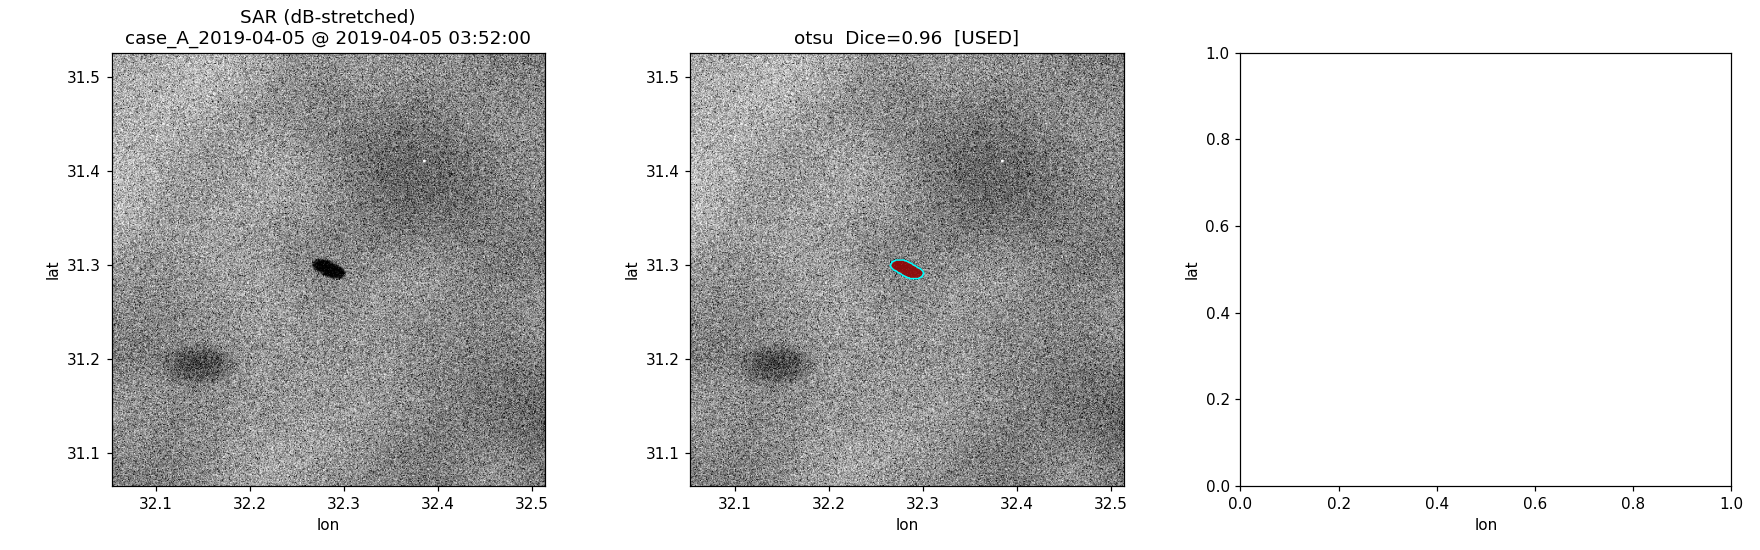

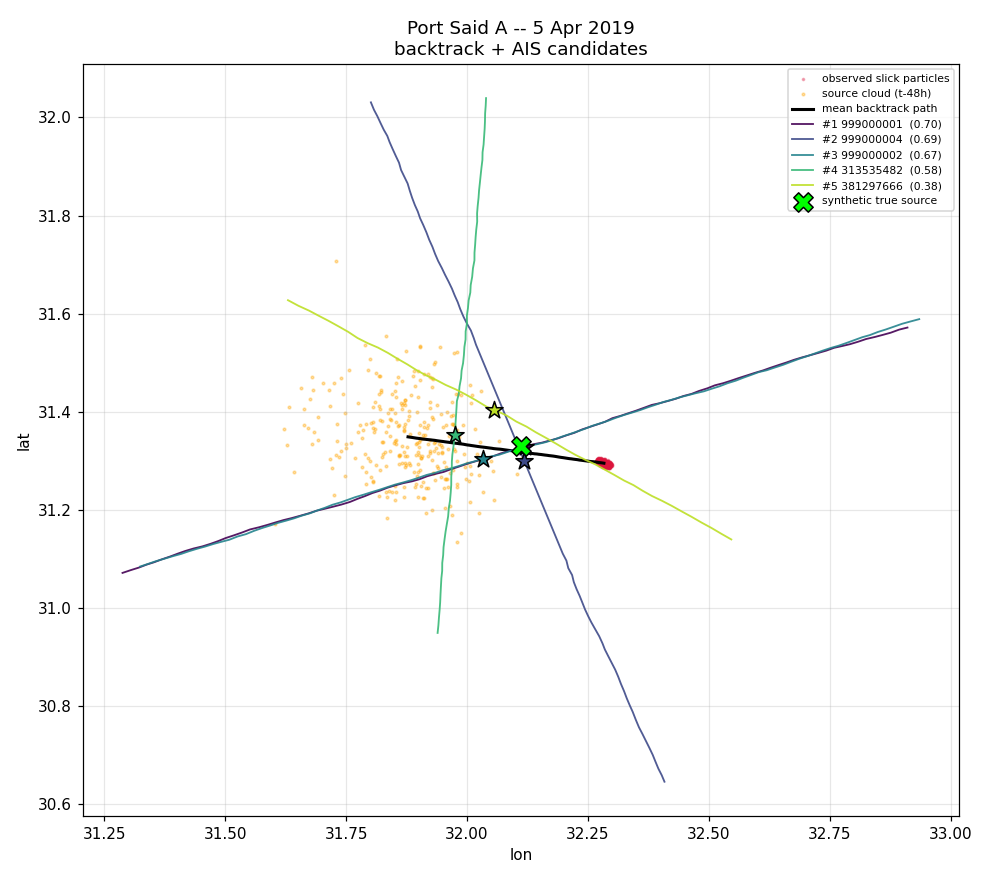

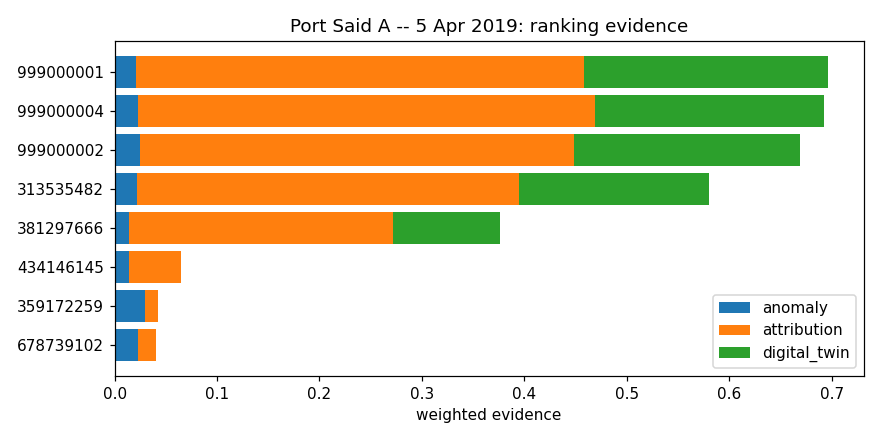

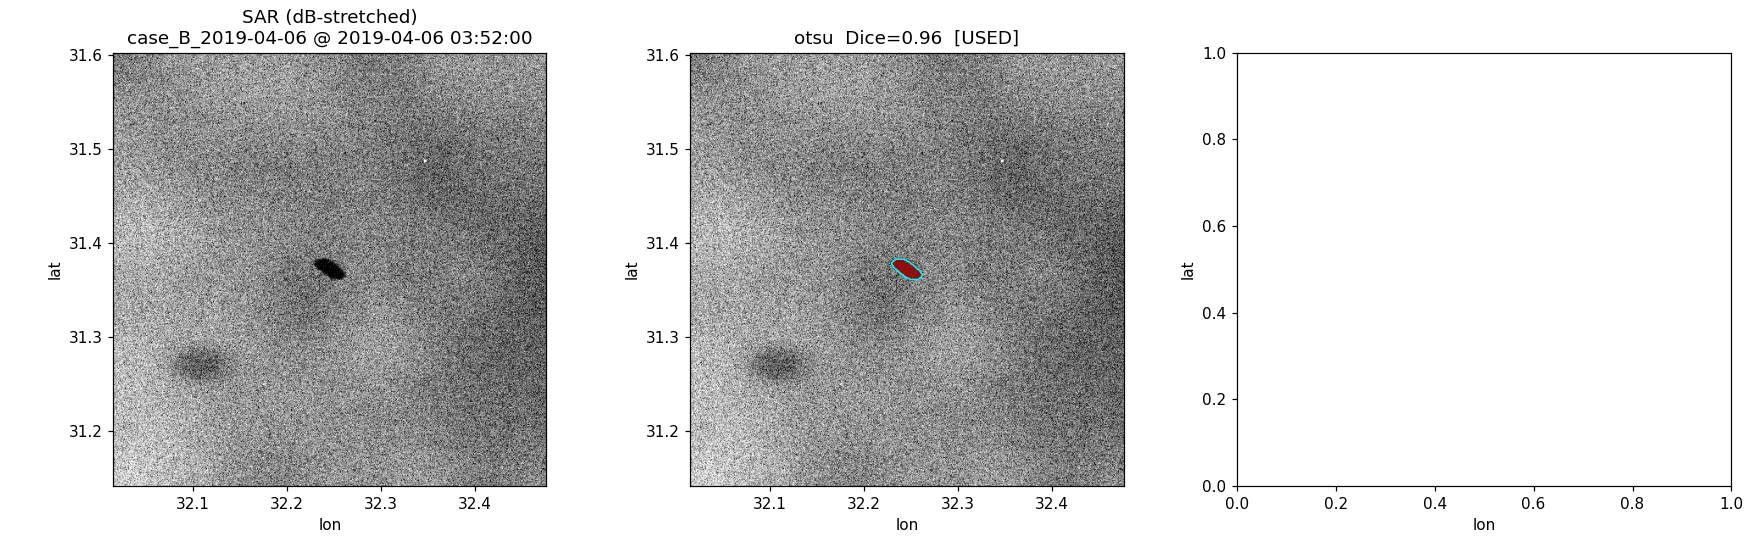

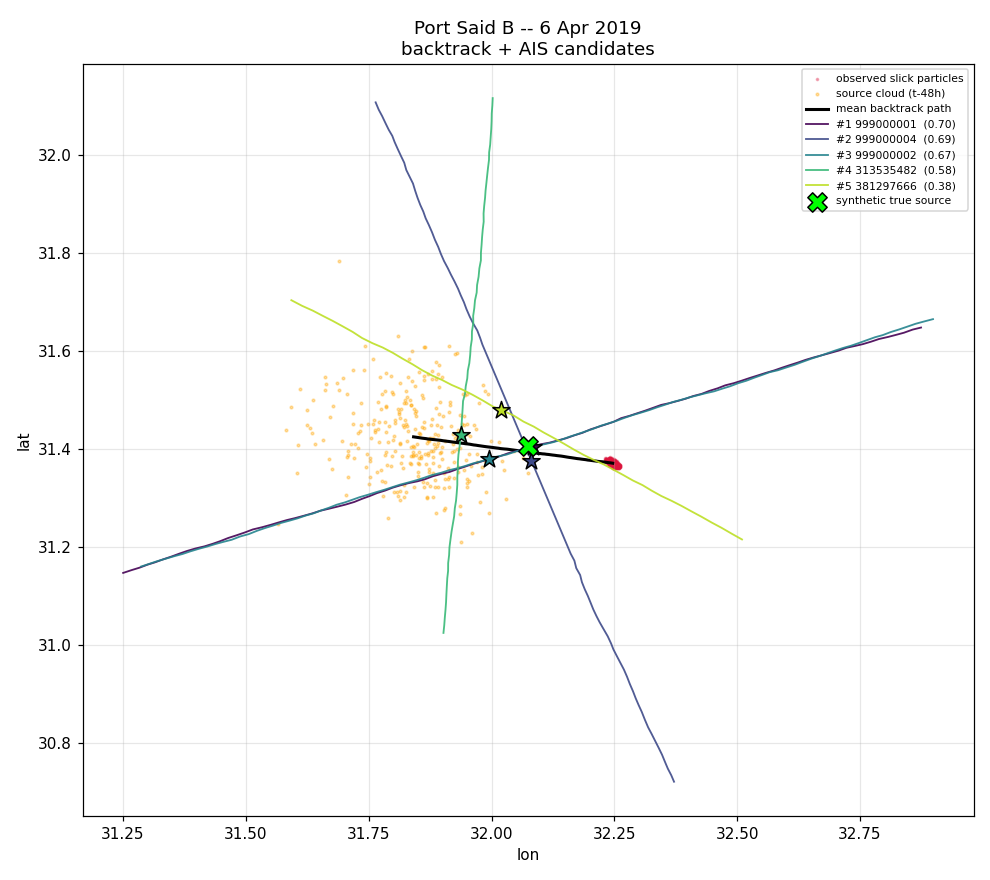

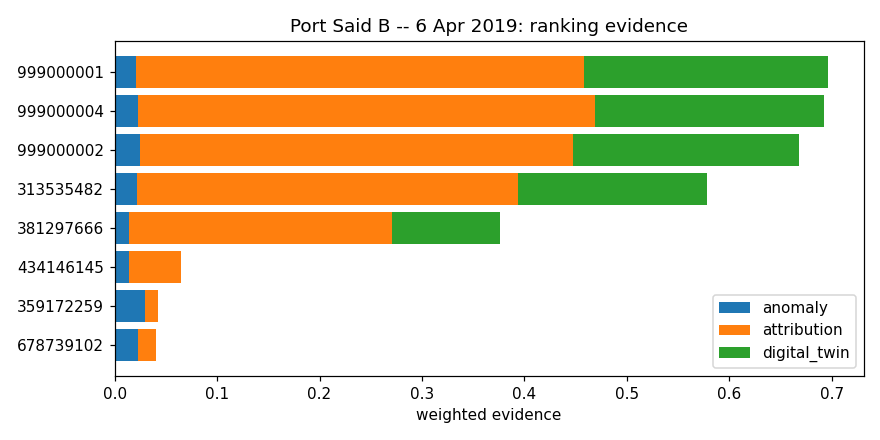

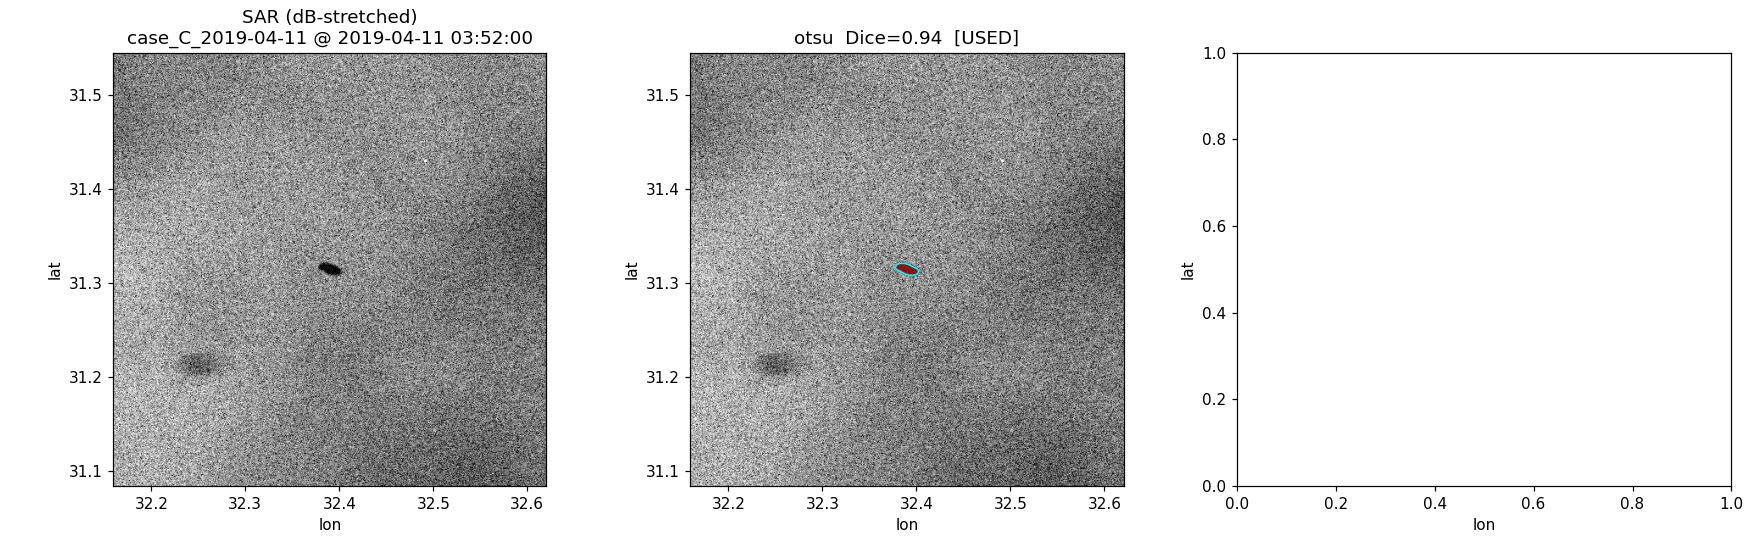

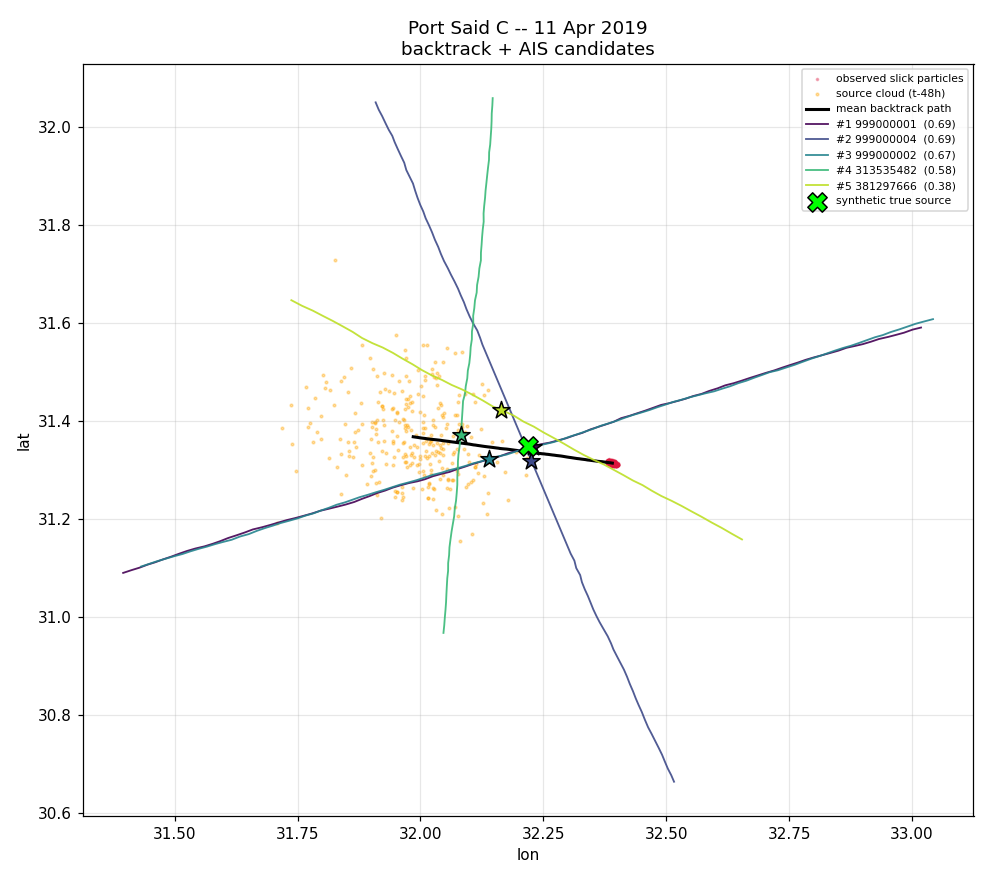

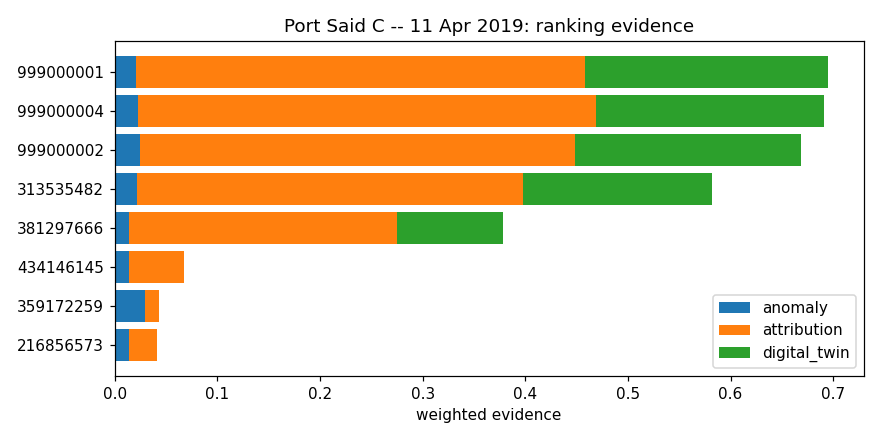

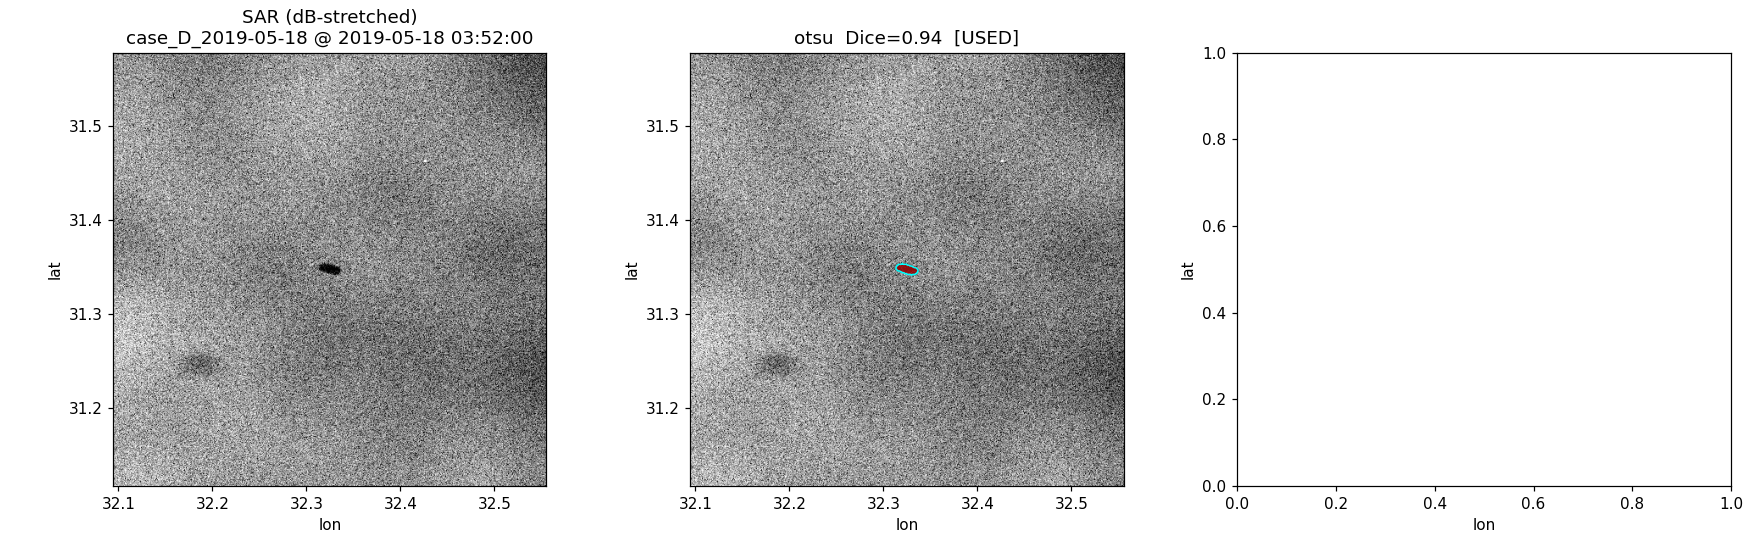

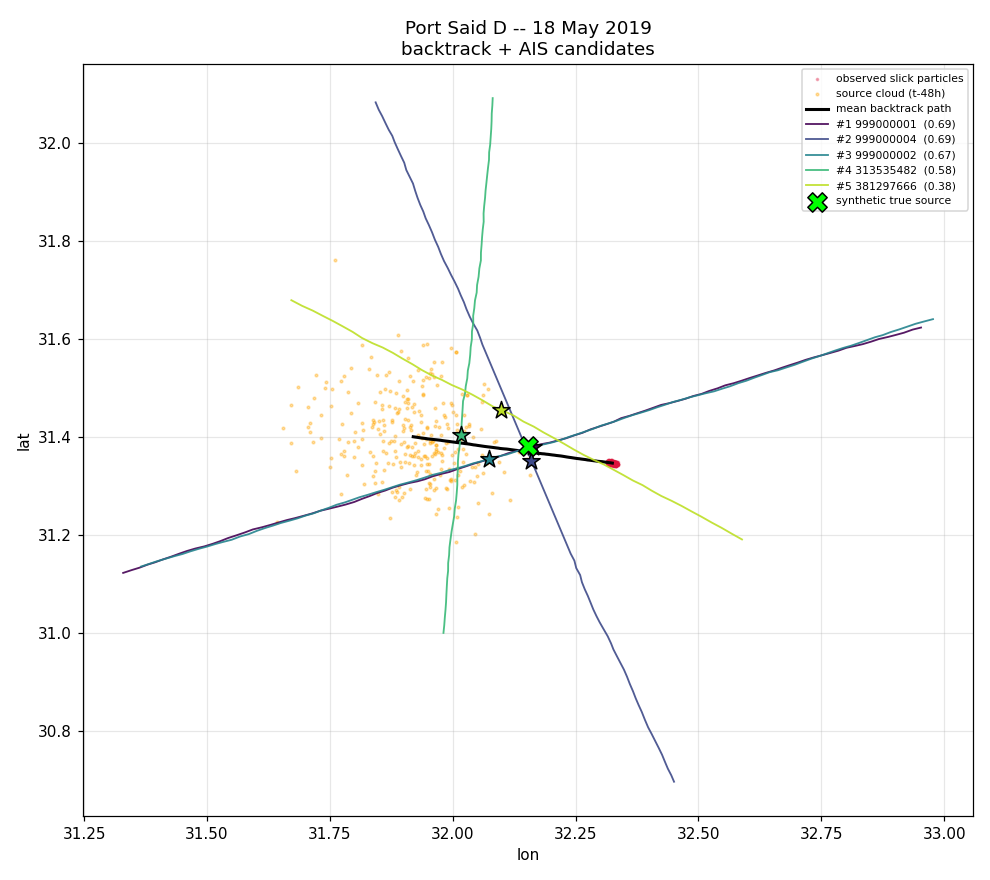

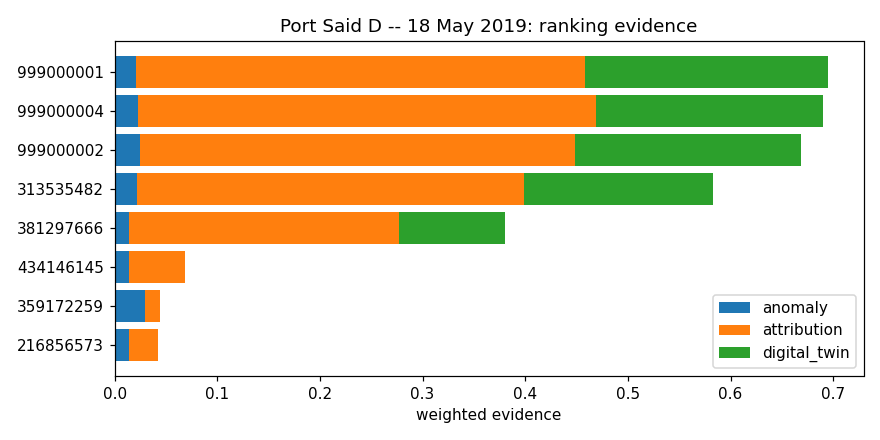

In [7]:
# ---- 6. figures ----
from IPython.display import Image, display
for r in results:
    for f in ("1_detection.png", "2_overview.png", "3_evidence.png"):
        p = os.path.join(r.out_dir, f)
        if os.path.exists(p): display(Image(p, width=900))

## Switching to REAL data -- checklist
1. **SAR**: georeferenced GeoTIFF (has a CRS) + a real acquisition time (raster tag `ACQUISITION_START_TIME`, a sidecar `.json` with `acquisition_time`, or pass `acquisition_time=` explicitly). Un-georeferenced PNG/JPG cannot be backtracked and is refused.
2. **Forcing**: `cfg.forcing.source="files"`; the loader *fails loudly* if the files do not cover the scene's area and the `backtrack_hours` before the pass, and refuses bottom-current variables.
3. **AIS**: `cfg.ais.source="csv"`. Columns are auto-detected (`MMSI, timestamp, lat, lon, sog, cog, name, type`) or mapped with `cfg.ais.column_map`.
4. **Classifier**: run Part A once, point `cfg.detection.bundle_dir` at its `deployment/` folder (or the zip). With `detection.mode="auto"` the pipeline benchmarks Otsu vs DeepLab and picks the better; give it `benchmark_dataset_root` for a labelled benchmark on your data.
5. Outputs per case: `ranked_suspects.csv`, `vessel_funnel.csv`, `case_report.json`, three PNGs. Lead levels are *investigative leads*, never accusations.